In [9]:
#import libraries
from astropy.io import fits
from astropy.wcs import WCS
from photutils.aperture import EllipticalAperture
from photutils.aperture import EllipticalAnnulus
from photutils.aperture import aperture_photometry
from astropy.coordinates import SkyCoord
import astropy.units as u
import pyregion
import numpy as np
from photutils.centroids import centroid_com
# from skimage.measure import regionprops, label
from astropy.nddata import Cutout2D
import matplotlib.pyplot as plt
#import statmorph
from photutils.segmentation import detect_sources
from astropy.visualization import ZScaleInterval, ImageNormalize

from matplotlib.patches import Ellipse
from astropy.visualization import simple_norm

import pandas as pd

from matplotlib.backends.backend_pdf import PdfPages

import warnings
warnings.simplefilter('ignore')

import Galaxy_info as gi

In [2]:
#file data
file = gi.Galaxy_Info["WLM"]

#galaxy name
galaxy = file[0]

#hi file
hi_fits = file[1]

#ha file
ha_fits = file[2]

#ha csv file
ha_csv = file[3]

#irac file
irac_fits = file[4]

#irac csv file
irac_csv = file[5]

#region file
region_file = file[6]

#distance to galxy kpc
distance = file[7]

In [16]:
# Load images

#hi image
hdu_hi = fits.open(hi_fits)
header_hi = hdu_hi[0].header
hi_image = hdu_hi[0].data
wcs_hi = WCS(header_hi)
cdelt = "CD2_2" if "CD2_2" in header_hi else "CDELT2"
arcsec_per_pixel_hi = np.abs(header_hi[cdelt]) * 3600

#ha image
hdu_ha = fits.open(ha_fits)
header_ha = hdu_ha[0].header
ha_image = hdu_ha[0].data
wcs_ha = WCS(header_ha)
cdelt = "CD2_2" if "CD2_2" in header_ha else "CDELT2"
arcsec_per_pixel_ha = np.abs(header_ha[cdelt]) * 3600
unit_ha = (10**header_ha["FLUX_CAL"]) / 1539

#irac 8 micron image
hdu_irac = fits.open(irac_fits)
header_irac = hdu_irac[0].header
irac_image = hdu_irac[0].data
wcs_irac = WCS(header_irac)
cdelt = "CD2_2" if "CD2_2" in header_irac else "CDELT2"
arcsec_per_pixel_irac = np.abs(header_irac[cdelt]) * 3600

In [4]:
#load csvs

#load ha csv
ha_df = pd.read_csv(ha_csv)

#load irac csv
irac_df = pd.read_csv(irac_csv)

In [5]:
#header_ha

In [6]:
#core to rim integration
def sum_core_to_rim(center, elongation, theta, image, arcsecs_per_pixel, axis_pix, radius_scalar=2):
    '''
    Calculates the flux over an ellipse
    Accepts: Center of Elipse in (x, y), elongation, theta (rads), image, arcsecs per pixel, semi-major axis (pixels),
    max scale for radius (int)
    Retuns: Array of radii, Array of summed flux at each radii
    '''

    #initialize flux array
    all_flux = []

    #initialize radii
    radii = []

    #initilize radius
    radius = int(radius_scalar * axis_pix * arcsecs_per_pixel)

    #initialize step
    step = 2

    #loop from center to radius
    for arcsecs in range(2, radius, step):

        #initialize ellipse radius
        radius_a = arcsecs / arcsecs_per_pixel
        radius_b = radius_a / elongation

        #add radius_a to radii
        radii = np.append(radii, arcsecs)

        #initialize aperature
        aperature = EllipticalAperture(center, radius_a, radius_b, theta)

        #calculate flux
        flux = aperture_photometry(image, aperature)['aperture_sum'][0]

        #add flux to all_flux
        all_flux = np.append(all_flux, flux)

    #return radii, and all_flux
    return radii, all_flux

def cut_mark_image(center, pixel_size_a, pixel_size_b, theta, image):
    '''
    Cuts image around center and creates ellipse around center
    Accepts: center (x, y), pixel height, pixel width, theta (rads), image
    Returns: cut image, ellipse defined around center
    '''

    #initialize parameters
    cutout_scale = 5
    ellipse_scale = 2

    try:
        #cut image
        cutout_obj = Cutout2D(data=image, position=center, size=pixel_size_a*cutout_scale)
        cutout = cutout_obj.data 
    
        #center of cutout
        x_c, y_c = cutout_obj.input_position_cutout
    
        #define ellipse
        ellipse = Ellipse((x_c, y_c), width=pixel_size_a*ellipse_scale, height=pixel_size_b*ellipse_scale,
                       angle=np.degrees(theta), edgecolor='k', facecolor='none', lw=4)
    except:
        return None, None

    #return cutout and region ellipse
    return cutout, ellipse

def rim_core_ratio(flux_array, rim_start=-2):
    '''
    Calculates rim to core ratio
    Accepts: Array of cumulative flux
    Returns: Ratio of rim to core
    '''

    #initialize core flux
    core = flux_array[0]

    #calculate rim flux
    rim = flux_array[-1] - flux_array[rim_start]

    #calculate rim to core ratio
    rim_core_ratio = rim / core

    #return rim to core ratio
    return rim_core_ratio

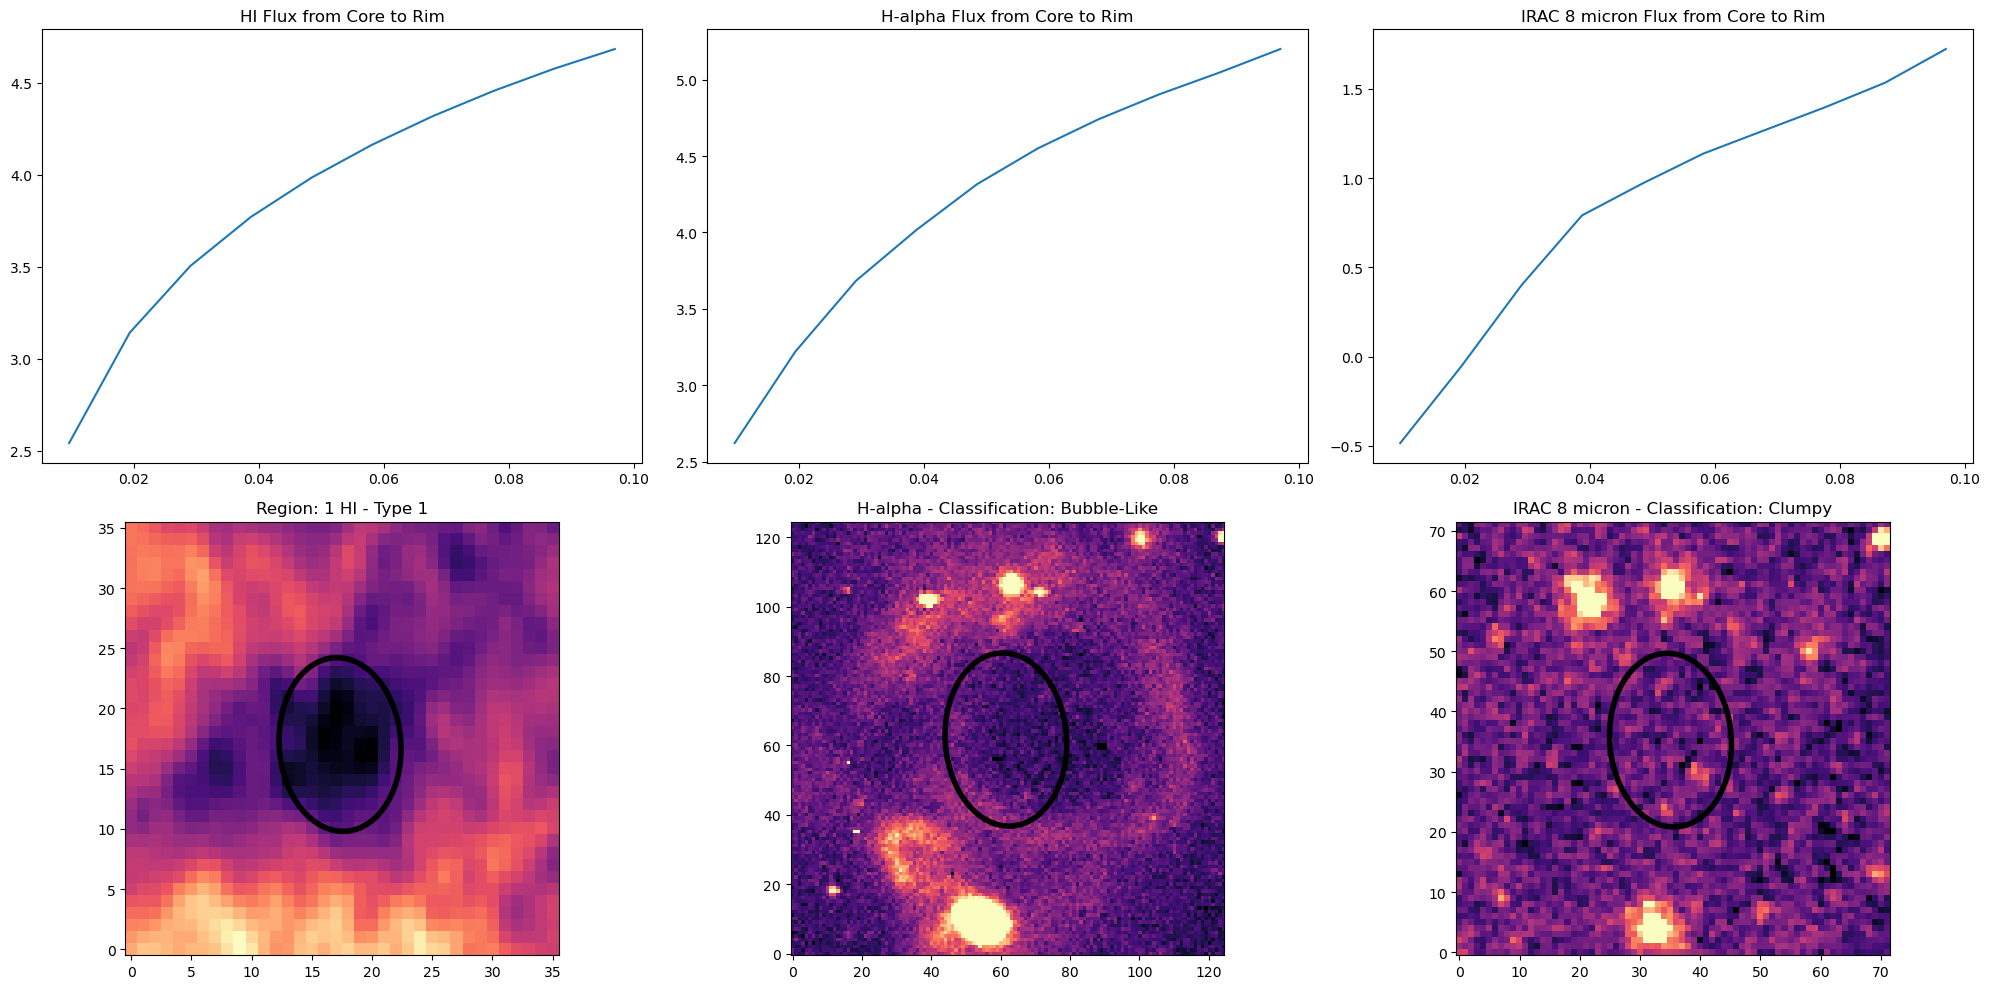

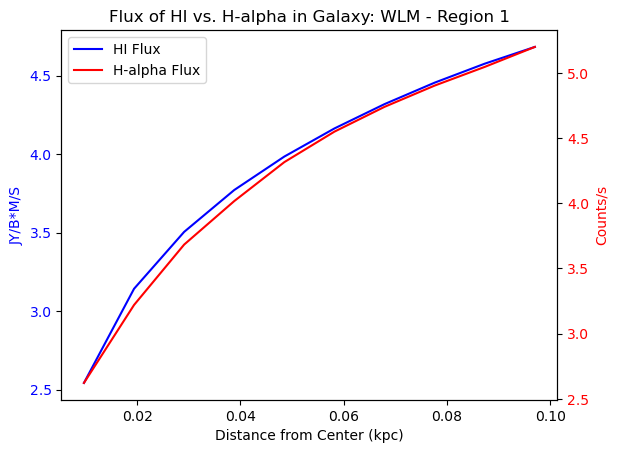

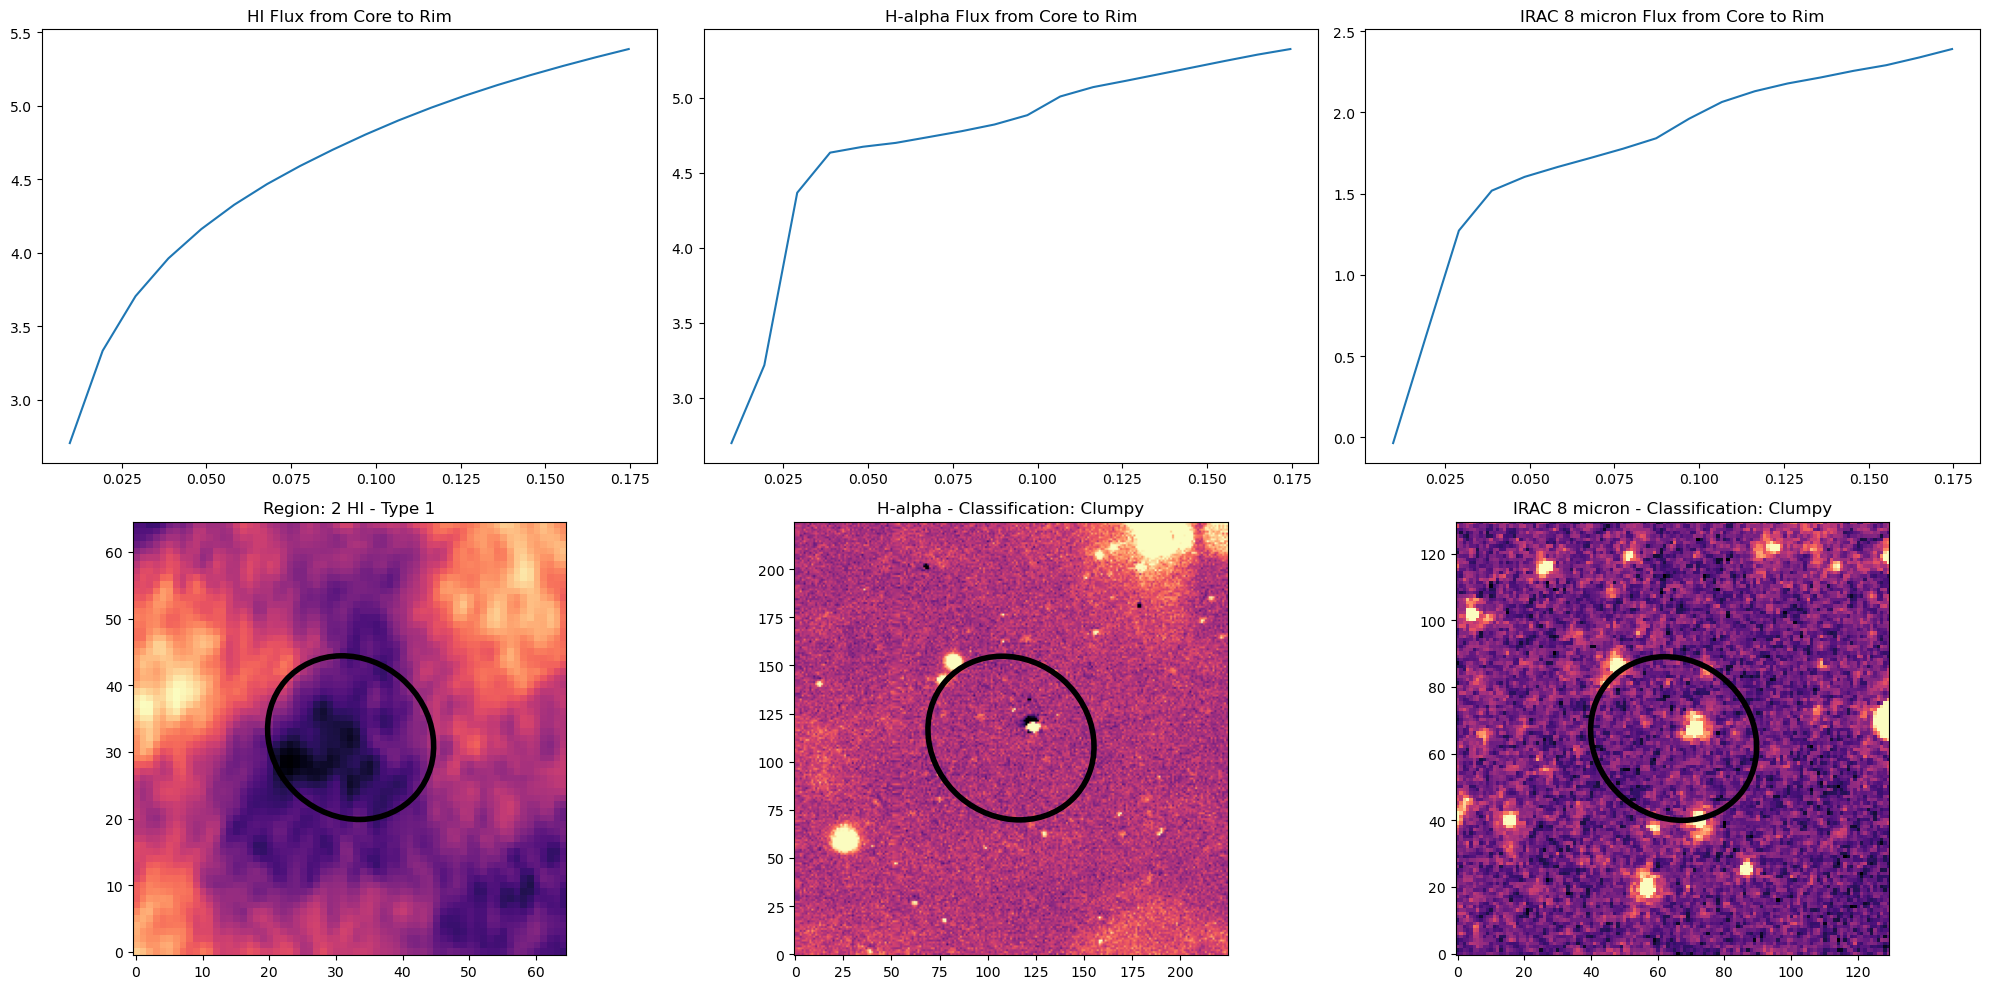

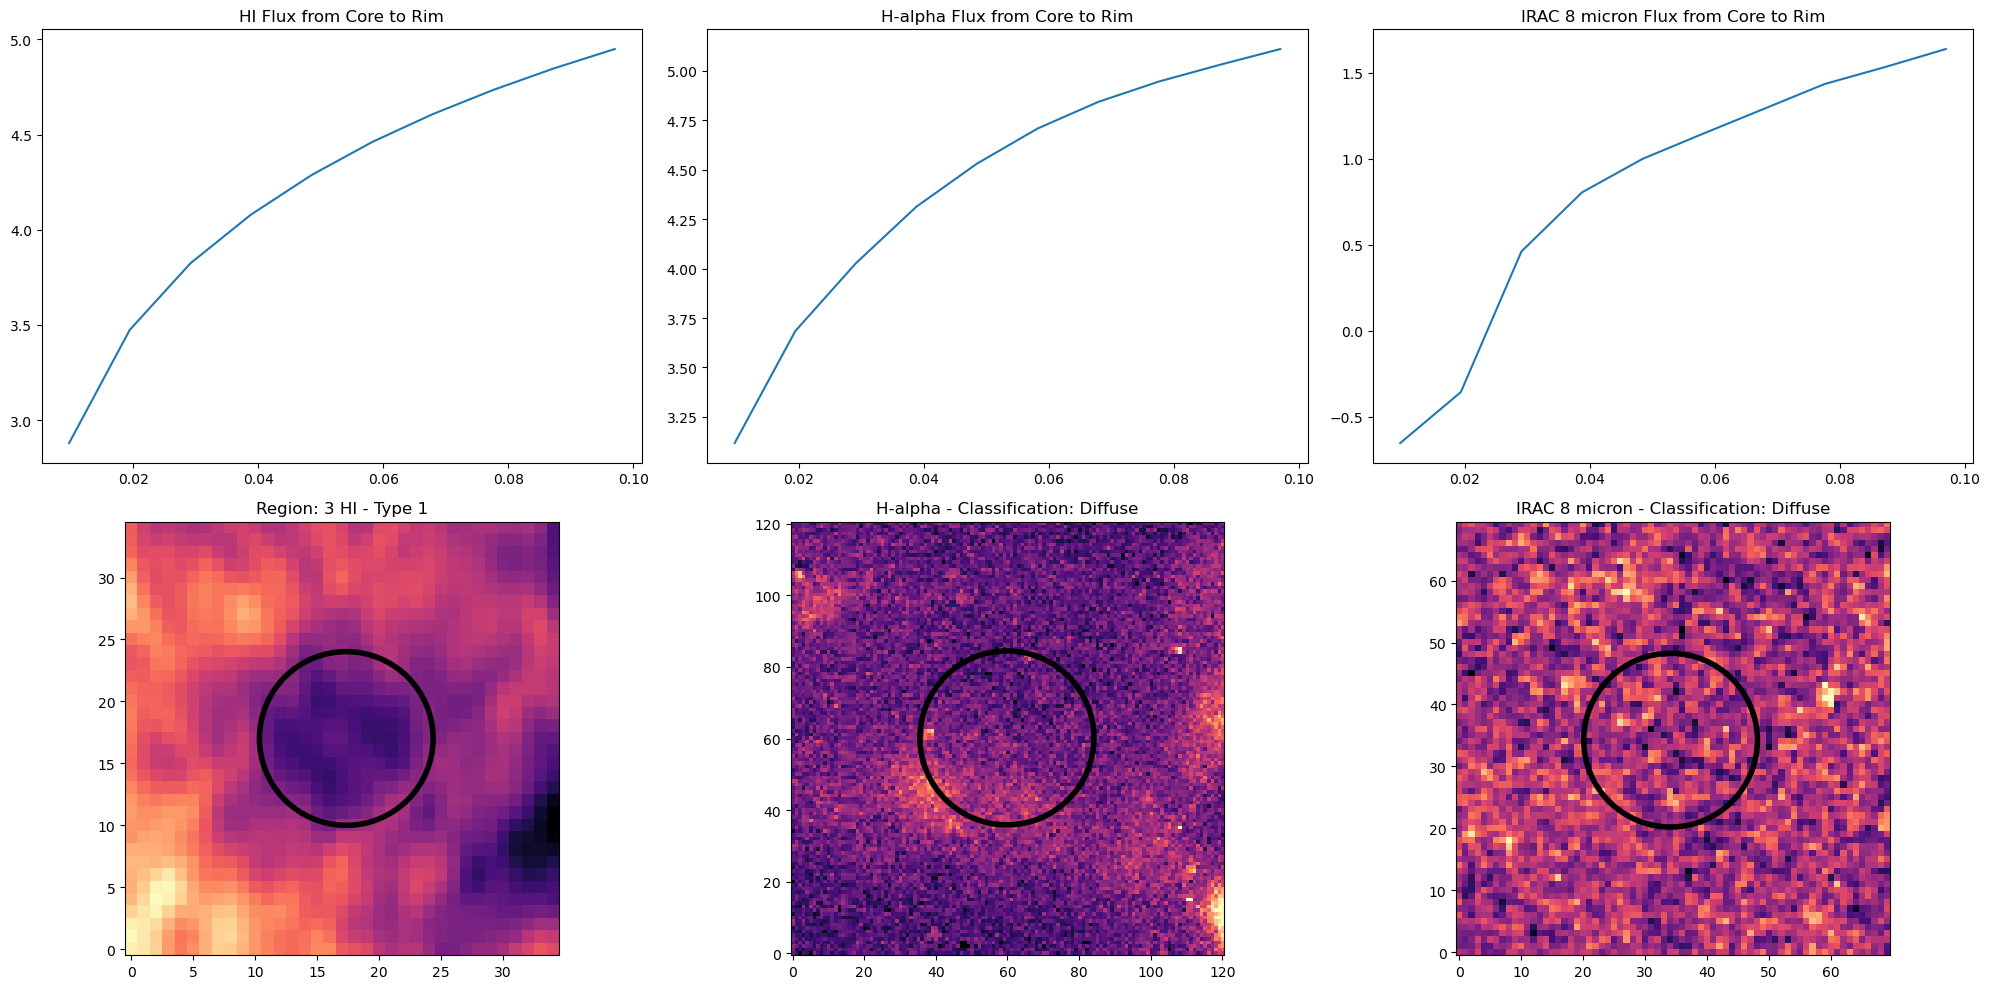

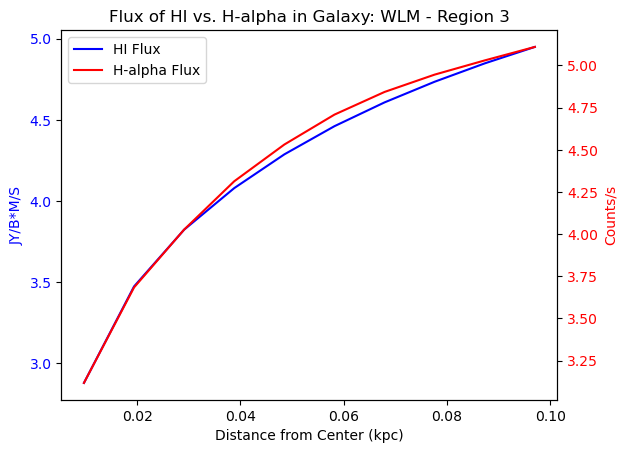

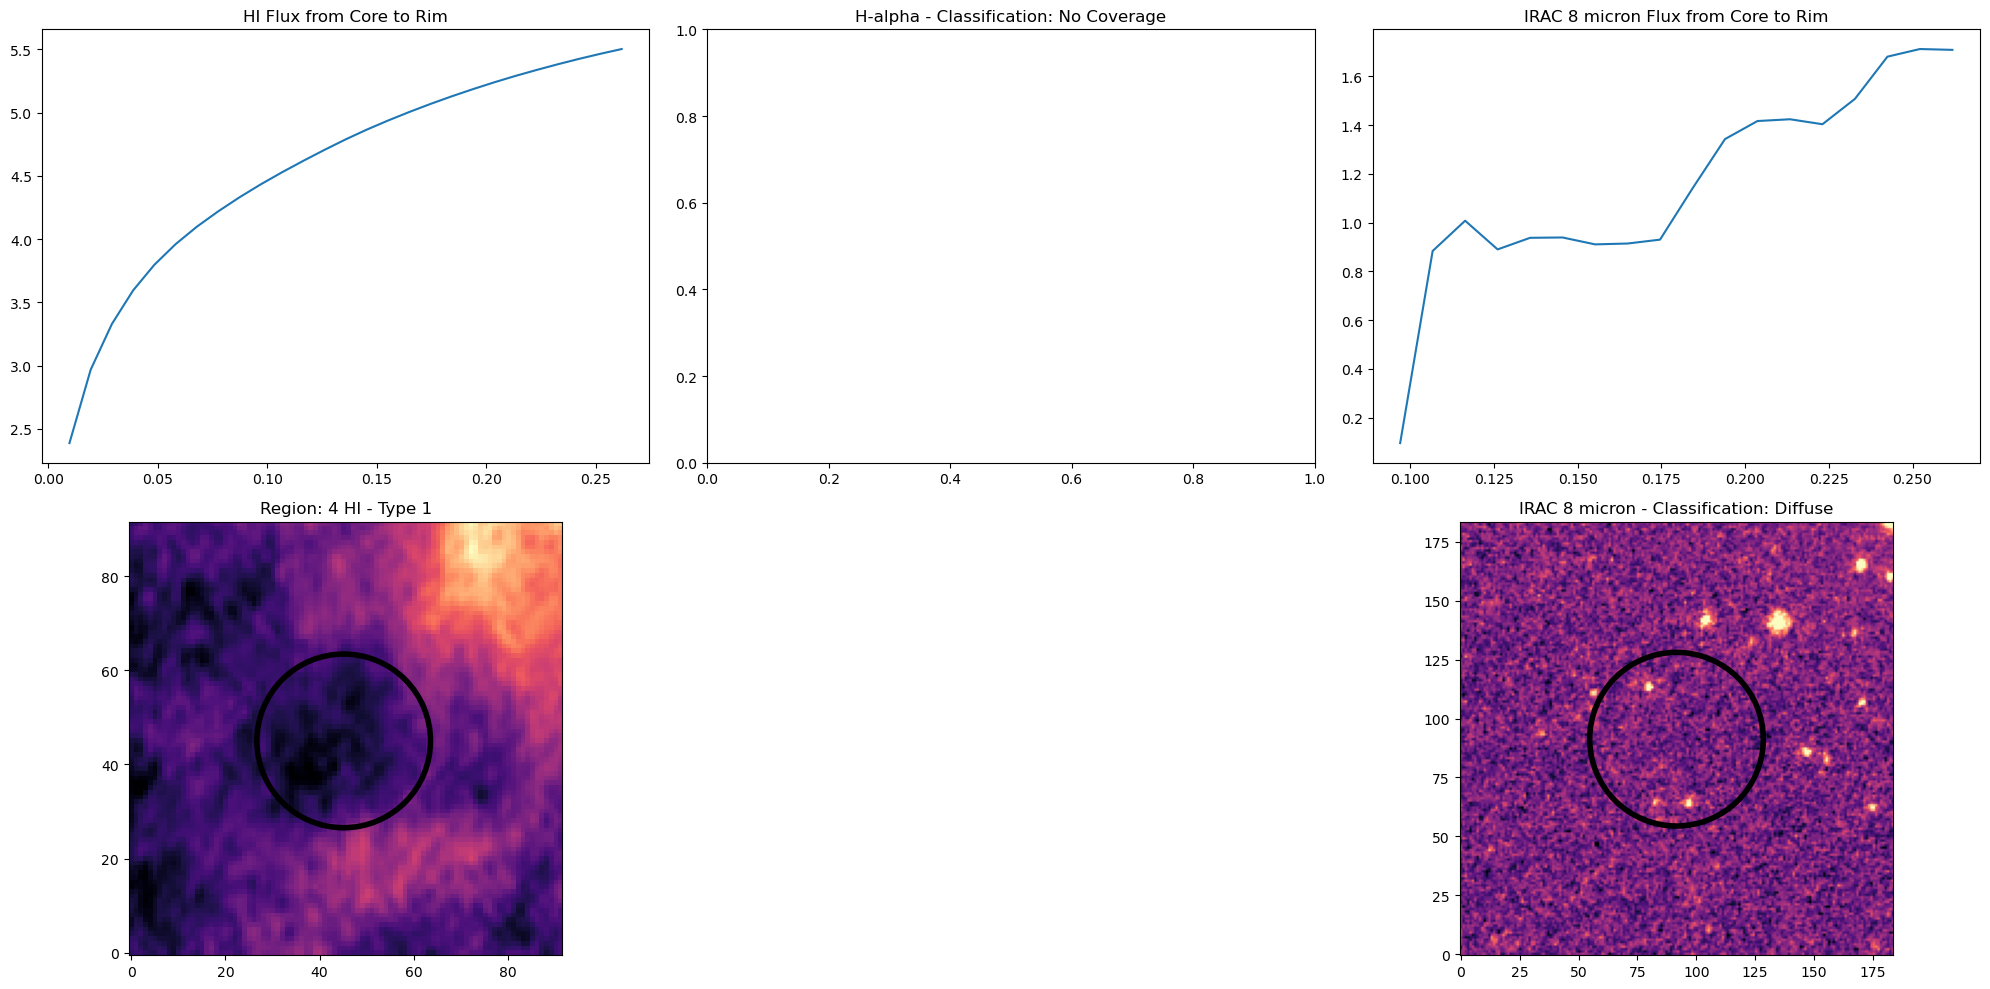

In [18]:
#load regions
regions = pyregion.open(region_file)

#initialize zscale
zscale = ZScaleInterval()

#open or create pdf
#with PdfPages(f"{galaxy}.pdf") as pdf:
if True:

    #iterate through regions
    for index, region in enumerate(regions):
    
        #check if applicable region
        if region.name != "ellipse":
            continue
    
        #grab coords of region center
        #coord_list: [RA, Dec, a_arcsec, b_arcsec, PA]
        ra, dec, a_arcsec, b_arcsec, pa_deg = region.coord_list
    
        #convert region center to pixel
        skycoord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
        x_hi, y_hi = skycoord.to_pixel(wcs_hi)
        x_ha, y_ha = skycoord.to_pixel(wcs_ha)
        x_irac, y_irac = skycoord.to_pixel(wcs_irac)
    
        #convert to rads
        theta = np.deg2rad(pa_deg)
    
        #convert hi arcsec → pixels
        a_pix_hi = a_arcsec * 3600/ arcsec_per_pixel_hi 
        b_pix_hi = b_arcsec * 3600/ arcsec_per_pixel_hi
    
        #convert ha arcsec → pixels
        a_pix_ha = a_arcsec * 3600/ arcsec_per_pixel_ha
        b_pix_ha = b_arcsec * 3600/ arcsec_per_pixel_ha
    
        #convert irac arcsec → pixels
        a_pix_irac = a_arcsec * 3600/ arcsec_per_pixel_irac
        b_pix_irac = b_arcsec * 3600/ arcsec_per_pixel_irac

        #initialize image figure
        plt.figure(figsize=(20, 10))

        ##########################################################
        ### HI ###################################################
        ##########################################################

        #hi flux subplot
        plt.subplot(231)

        try:
            #calculate hi flux
            radii_hi, flux_hi = sum_core_to_rim((x_hi, y_hi), a_pix_hi/b_pix_hi, theta, hi_image.squeeze(), \
                                                     arcsec_per_pixel_hi, a_pix_hi)

            #convert radii to kpc
            radii_hi = radii_hi * distance * 4.85 * (10**-6)
            
            #plot hi flux
            plt.plot(radii_hi, np.log10(flux_hi))
            plt.title(f"HI Flux from Core to Rim")
        except:
            #plot failed
            plt.title(f"Failed")

        #initialize hi cutout subplot
        plt.subplot(234)
    
        #check if valid coords in hi
        if(x_hi>0 and y_hi>0):
    
            #get hi hole type
            hi_hole_type = ha_df["HI Hole Type"][index]

            #remove empty dimensions from hi data
            data_hi = hi_image.squeeze()

            #cut image and define region ellipse
            cutout_hi, core_ellipse = cut_mark_image((x_hi, y_hi), a_pix_hi, b_pix_hi, theta, data_hi)
            
            #check if cutout exists
            if type(cutout_hi) == "NoneType":
                continue
    
            #plot hi cut and region
            vmin, vmax = zscale.get_limits(cutout_hi)
            plt.imshow(cutout_hi, origin='lower', cmap='magma', vmin=vmin, vmax=vmax)# norm="symlog")

            #plot region ellipse
            plt.gca().add_patch(core_ellipse)

        #set hi title
        plt.title(f"Region: {index + 1} HI - Type {hi_hole_type}")
        plt.tight_layout()

        ##########################################################
        ### H-alpha ##############################################
        ##########################################################

        #initialize ha flux subplot
        plt.subplot(232)

        #get classification
        ha_class = ha_df["Classification"][index]

         #check if coverage
        if ha_class != "No Coverage" and ha_class != "No Emission":

            try:
                #calculate ha flux
                radii_ha, flux_ha = sum_core_to_rim((x_ha, y_ha), a_pix_ha/b_pix_ha, theta, ha_image, \
                                                         arcsec_per_pixel_ha, a_pix_ha)
        
                #convert radii to kpc
                radii_ha = radii_ha * distance * 4.85 * (10**-6)

                #convert flux to erg/s/cm2
                #flux_ha = flux_ha
                
                #plot ha flux
                plt.plot(radii_ha, np.log10(flux_ha))
                plt.title(f"H-alpha Flux from Core to Rim")
            except:
                #plot failed
                plt.title(f"Failed")
    
            #initialize ha cutout subplot
            plt.subplot(235)
    
            #check if valid coords in ha
            if (x_ha>0 and y_ha>0):
    
                #cut image and define region ellipse
                data_ha = ha_image
                cutout_ha, core_ellipse = cut_mark_image((x_ha, y_ha), a_pix_ha, b_pix_ha, theta, data_ha)
                
                #check id cutout exists
                if type(cutout_ha) == "NoneType":
                    continue
        
                #plot ha cut
                vmin, vmax = zscale.get_limits(cutout_ha)
                plt.imshow(cutout_ha, origin='lower', cmap='magma', vmin=vmin, vmax=vmax)# norm="log")#vmin=-130*unit, vmax=9*unit)
                
                #plot region ellipse
                plt.gca().add_patch(core_ellipse)

        #set ha title
        plt.title(f"H-alpha - Classification: {ha_class}")
        plt.tight_layout()

        ##########################################################
        ### IRAC 8 micron ########################################
        ##########################################################

        #initialize irac flux subplot
        plt.subplot(233)

        #get classification
        irac_class = irac_df["Classification"][index]

        #check if coverage
        if irac_class != "No Coverage" and irac_class != "No Emission":

            try:
                #calculate irac flux
                radii_irac, flux_irac = sum_core_to_rim((x_irac, y_irac), a_pix_irac/b_pix_irac, theta, irac_image, \
                                                         arcsec_per_pixel_irac, a_pix_irac)
        
                #convert radii to Mpc
                radii_irac = radii_irac * distance * 4.85 * (10**-6)
                
                #plot irac flux
                plt.plot(radii_irac, np.log10(flux_irac))
                plt.title(f"IRAC 8 micron Flux from Core to Rim")
            except:
                #plot failed
                plt.title(f"Failed")
    
            #initialize irac cutout subplot
            plt.subplot(236)
        
            #check if valid coords in irac
            if(x_irac>0 and y_irac>0):
        
                #cut image and define region ellipse
                data_irac = irac_image
                cutout_irac, core_ellipse = cut_mark_image((x_irac, y_irac), a_pix_irac, b_pix_irac, theta, data_irac)
                
                #check if cutout exists
                if type(cutout_irac) == "NoneType":
                    continue
        
                #plot irac cut
                vmin, vmax = zscale.get_limits(cutout_irac)
                plt.imshow(cutout_irac, origin='lower', cmap='magma', vmin=vmin, vmax=vmax)# norm="log")
                
                #plot region ellipse
                plt.gca().add_patch(core_ellipse)
        
        #set irac title
        plt.title(f"IRAC 8 micron - Classification: {irac_class}")
        plt.tight_layout()
        
        #save plots
        #pdf.savefig()
        
        #show cutouts
        plt.show()

        #plot hi flux against ha flux
        if ha_class != "No Coverage" and ha_class != "No Emission":

            if ha_class == "Bubble-Like" or ha_class == "Diffuse":

                #create main figure
                fig, ax1 = plt.subplots()
    
                #plot hi flux
                ax1.plot(radii_hi, np.log10(flux_hi), 'b-', label="HI Flux")
                ax1.set_xlabel("Distance from Center (kpc)")
                ax1.set_ylabel("JY/B*M/S", color='b')
                ax1.tick_params(axis='y', labelcolor='b')
    
                #create secondary y axis
                ax2 = ax1.twinx()
    
                #plot ha flux
                ax2.plot(radii_ha, np.log10(flux_ha), 'r-', label="H-alpha Flux")
                ax2.set_ylabel("Counts/s", color='r')
                ax2.tick_params(axis='y', labelcolor='r')
    
                #create legend
                lines = ax1.get_lines() + ax2.get_lines()
                labels = [l.get_label() for l in lines]
                ax1.legend(lines, labels, loc='upper left')
    
                #set title
                plt.title(f"Flux of HI vs. H-alpha in Galaxy: {galaxy} - Region {index + 1}")
    
                #show figure
                plt.show()

        #close fig
        plt.close()